In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# %pip uninstall -y numpy
# %pip install -q numpy==1.26.4
# %pip install --upgrade scipy scikit-learn threadpoolctl
%pip install gpflow 
#==2.9.2

^C
Note: you may need to restart the kernel to use updated packages.


  Using cached check_shapes-1.1.1-py3-none-any.whl.metadata (2.4 kB)
  Using cached deprecated-1.3.1-py2.py3-none-any.whl.metadata (5.9 kB)
  Using cached multipledispatch-1.0.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached tabulate-0.10.0-py3-none-any.whl.metadata (40 kB)
  Using cached tensorflow_probability-0.25.0-py2.py3-none-any.whl.metadata (13 kB)
  Using cached tensorflow-2.21.0-cp312-cp312-win_amd64.whl.metadata (4.5 kB)
  Using cached dropstackframe-0.1.1-py3-none-any.whl.metadata (4.3 kB)
  Using cached lark-1.3.1-py3-none-any.whl.metadata (1.8 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cac

In [3]:
import numpy as np
# from sklearn.calibration import LabelEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.discriminant_analysis import StandardScaler
from sklearn.metrics import classification_report
import pandas as pd
from datetime import datetime
import gpflow
import tensorflow as tf
import warnings
from prettytable import PrettyTable
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import trange,tqdm
from sklearn.metrics import accuracy_score
warnings.filterwarnings('ignore')

def print_table(df: pd.DataFrame):
    top_rows = df.copy()
    table = PrettyTable()
    table.field_names = top_rows.columns.tolist()
    for _, row in top_rows.iterrows():
        table.add_row(row.tolist())
    print(table)

In [4]:
df_audit_grade = pd.read_parquet(r'H:\My Drive\Projects_mdw\BayesAudit\Data\audit_grading.parquet')
# df_audit_grade = pd.read_parquet(r'/content/drive/MyDrive/Projects_mdw/BayesAudit/Data/audit_grading.parquet')
print(df_audit_grade.shape)
print(df_audit_grade.columns)
df_audit_grade.head()

(413, 3)
Index(['Site_ID', 'Shop Grade', 'Current Audit Date'], dtype='object')


,Site_ID,Shop Grade,Current Audit Date
0,S001,B,2025-09-11
1,S002,C-,2025-08-11
2,S003,B,2025-05-14
3,S004,A,2025-07-09
4,S005,B,2025-02-06


In [5]:
df_dim_store = df_audit_grade[['Site_ID']]
df_dim_store.drop_duplicates(inplace=True)
print(df_dim_store.shape)
df_dim_store.head()

(413, 1)


,Site_ID
0,S001
1,S002
2,S003
3,S004
4,S005


### Preprocess Audit Grades Data

In [6]:
df_audit_grade['Current Audit Date'] = pd.to_datetime(df_audit_grade['Current Audit Date'])

current_date = df_audit_grade['Current Audit Date'].max()
days_count =  60 # current_date.day + 31 #+30

df_audit_grade = df_audit_grade[(current_date - df_audit_grade['Current Audit Date']).dt.days <= days_count]
print('df_audit_grade shape :',df_audit_grade.shape)
print('df_audit_grade Min date :',df_audit_grade['Current Audit Date'].min())
print('df_audit_grade Max date :',df_audit_grade['Current Audit Date'].max())

df_audit_grade shape : (116, 3)
df_audit_grade Min date : 2025-08-25 00:00:00
df_audit_grade Max date : 2025-10-24 00:00:00


In [8]:
# df_kpi_score = pd.read_parquet(r'/content/drive/MyDrive/Projects_mdw/BayesAudit/Data/kpi_scores.parquet')
df_kpi_score = pd.read_parquet(r'H:\My Drive\Projects_mdw\BayesAudit\Data\kpi_scores.parquet')
print(df_kpi_score.shape)
print(df_kpi_score.columns)
df_kpi_score.head()

(58013, 24)
Index(['EDATE', 'INVENTORY_TURNOVER_RTO_RISK_SCORE',
       'PRODUCTRELEASE_COST_RTO_RISK_SCORE',
       'BLACKLIST_CUST_ACTIVE_ACC_RISK_SCORE', 'PH_NO_CHANGE_CUST_RISK_SCORE',
       'EARL_CLOS_DISCOUNT_RISK_SCORE', 'HIRE_SALE_ASS_ACC_RISK_SCORE',
       'CASHA_RISK_SCORE', 'ACC_LESS_ADD_PAY_RISK_SCORE',
       'ISSUE_RTO_RISK_SCORE', 'cash_coll_vs_banking_rto',
       'UNSALEABLE_INVENTORY_RTO', 'REVERT_INVENTORY_RTO',
       'TOT_UNPAID_CASH_SALES_RISK', 'TOT_HP_ARREARS_RISK_RTO',
       'TOT_CRDT_OUTSTN_AMT_DUE_DAYS_RLN', 'RETURN_CHEQUE_RISK_SCORE',
       'SPECIAL_DISCOUNT_RISK_SCORE', 'MULTI_HP_ACC_PER_CUST_RISK_SCORE',
       'INITIAL_PAYMENT_NOT_PAID_RISK_SCORE', 'SALES_RETURN_RISK_SCORE',
       'PRODUCT_MANUAL_ORDERS_RISK_SCORE', 'SHORT_REMIT_RISK_SCORE',
       'Site_ID'],
      dtype='object')


,EDATE,INVENTORY_TURNOVER_RTO_RISK_SCORE,PRODUCTRELEASE_COST_RTO_RISK_SCORE,BLACKLIST_CUST_ACTIVE_ACC_RISK_SCORE,PH_NO_CHANGE_CUST_RISK_SCORE,EARL_CLOS_DISCOUNT_RISK_SCORE,HIRE_SALE_ASS_ACC_RISK_SCORE,CASHA_RISK_SCORE,ACC_LESS_ADD_PAY_RISK_SCORE,ISSUE_RTO_RISK_SCORE,...,TOT_HP_ARREARS_RISK_RTO,TOT_CRDT_OUTSTN_AMT_DUE_DAYS_RLN,RETURN_CHEQUE_RISK_SCORE,SPECIAL_DISCOUNT_RISK_SCORE,MULTI_HP_ACC_PER_CUST_RISK_SCORE,INITIAL_PAYMENT_NOT_PAID_RISK_SCORE,SALES_RETURN_RISK_SCORE,PRODUCT_MANUAL_ORDERS_RISK_SCORE,SHORT_REMIT_RISK_SCORE,Site_ID
0,2025-09-20,0.842112,0.500000,0.013710,0.014951,0.000000,0.000000,0.145757,NaN,0.0,...,0.018022,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S254
1,2025-09-20,0.825651,0.430075,0.000000,0.499210,0.000000,0.000000,0.091817,NaN,0.0,...,0.047599,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S013
2,2025-09-20,0.857242,0.406463,0.000000,0.210004,0.241084,0.688894,0.414772,NaN,0.0,...,0.013334,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S467
3,2025-09-20,0.323289,0.413312,0.005499,0.020825,0.000000,0.863735,0.708144,NaN,0.0,...,0.084018,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S231
4,2025-09-20,0.821366,0.412756,0.003485,0.400223,0.272825,0.000000,0.833605,NaN,0.0,...,0.025874,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S478


### Preprocess KPI Scores Data

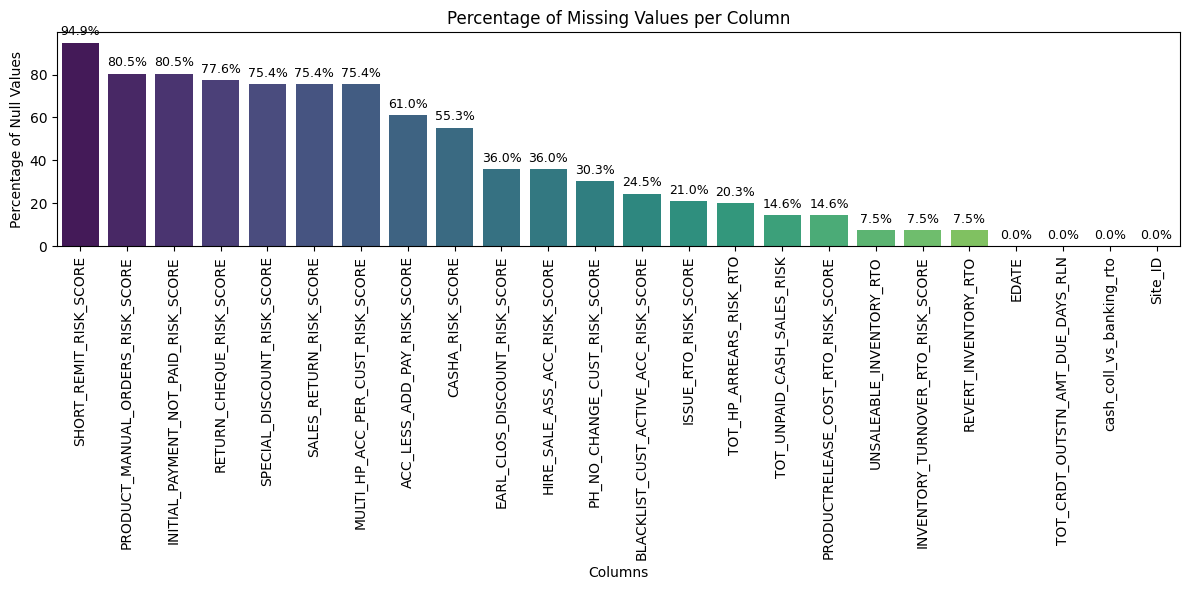

In [9]:
df_kpi_score['EDATE'] = pd.to_datetime(df_kpi_score['EDATE'])
null_df_kpi_score = pd.DataFrame(df_kpi_score.isnull().sum(),columns=['Null_Count'])
null_df_kpi_score['Null_Count'] = (null_df_kpi_score['Null_Count'] / df_kpi_score.shape[0])*100
null_df_kpi_score=null_df_kpi_score.sort_values(by='Null_Count',ascending=False)
# null_df_kpi_score.head(null_df_kpi_score.shape[0])

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x=null_df_kpi_score.index,
    y=null_df_kpi_score['Null_Count'],
    palette='viridis'
)
plt.xticks(rotation=90)
plt.ylabel('Percentage of Null Values')
plt.xlabel('Columns')
plt.title('Percentage of Missing Values per Column')

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9,
        xytext=(0, 3),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()

In [10]:
drop_columns = null_df_kpi_score[null_df_kpi_score['Null_Count']>25].index
print(drop_columns)

df_kpi_score.drop(drop_columns,axis=1,inplace=True)
df_kpi_score.head()

Index(['SHORT_REMIT_RISK_SCORE', 'PRODUCT_MANUAL_ORDERS_RISK_SCORE',
       'INITIAL_PAYMENT_NOT_PAID_RISK_SCORE', 'RETURN_CHEQUE_RISK_SCORE',
       'SPECIAL_DISCOUNT_RISK_SCORE', 'SALES_RETURN_RISK_SCORE',
       'MULTI_HP_ACC_PER_CUST_RISK_SCORE', 'ACC_LESS_ADD_PAY_RISK_SCORE',
       'CASHA_RISK_SCORE', 'EARL_CLOS_DISCOUNT_RISK_SCORE',
       'HIRE_SALE_ASS_ACC_RISK_SCORE', 'PH_NO_CHANGE_CUST_RISK_SCORE'],
      dtype='object')


,EDATE,INVENTORY_TURNOVER_RTO_RISK_SCORE,PRODUCTRELEASE_COST_RTO_RISK_SCORE,BLACKLIST_CUST_ACTIVE_ACC_RISK_SCORE,ISSUE_RTO_RISK_SCORE,cash_coll_vs_banking_rto,UNSALEABLE_INVENTORY_RTO,REVERT_INVENTORY_RTO,TOT_UNPAID_CASH_SALES_RISK,TOT_HP_ARREARS_RISK_RTO,TOT_CRDT_OUTSTN_AMT_DUE_DAYS_RLN,Site_ID
0,2025-09-20,0.842112,0.500000,0.013710,0.0,0.0,0.043791,0.047997,0.000000,0.018022,0.0,S254
1,2025-09-20,0.825651,0.430075,0.000000,0.0,0.0,0.016666,0.026522,0.047185,0.047599,0.0,S013
2,2025-09-20,0.857242,0.406463,0.000000,0.0,0.0,0.005226,0.037853,0.000000,0.013334,0.0,S467
3,2025-09-20,0.323289,0.413312,0.005499,0.0,0.0,0.019839,0.092460,0.000000,0.084018,0.0,S231
4,2025-09-20,0.821366,0.412756,0.003485,0.0,0.0,0.001064,0.046433,0.102690,0.025874,0.0,S478


### Feature Builder (Dynamic Window)

In [ ]:
def build_feature_df(window_size):
    feature_df = []
    sites = df_dim_store['Site_ID'].unique()

    for site in sites:
        try:
            audit_row = df_audit_grade[df_audit_grade['Site_ID'] == site].iloc[0]
            audit_date = audit_row['Current Audit Date'].date()
            audit_grade = audit_row['Shop Grade']
        except:
            audit_date = df_kpi_score['EDATE'].max().date()
            audit_grade = None

        sub = df_kpi_score[
            (df_kpi_score['Site_ID'] == site) &
            (df_kpi_score['EDATE'].dt.date <= audit_date)
        ].sort_values(by='EDATE', ascending=False).reset_index(drop=True)

        if len(sub) < window_size:
            continue

        for i in range(window_size):
            row = {
                'branch': site,
                'grade': audit_grade,
                'day': i + 1,
                'rundate': sub.loc[i, 'EDATE']
            }

            for col in sub.columns:
                if col not in ['Site_ID', 'EDATE']:
                    row[col] = sub.loc[i, col]

            feature_df.append(row)

    return pd.DataFrame(feature_df)

def build_input_matrix(df, feature_cols):
    times = df['day'].values.reshape(-1, 1)
    feats = df[feature_cols].values
    return np.hstack([times, feats]).astype(np.float64)

def run_experiment(window_size):

    print(f"\n===== Running {window_size} Days Window =====")

    feature_df = build_feature_df(window_size)

    if feature_df.empty:
        print("No data available")
        return None

    graded_df = feature_df.dropna(subset=['grade']).copy()
    graded_df.fillna(0, inplace=True)

    if graded_df.empty:
        print("No graded data")
        return None

    # Encode labels
    le = LabelEncoder()
    y = le.fit_transform(graded_df['grade'])
    grades = le.classes_

    feature_cols = list(
        feature_df.drop(columns=['branch', 'grade', 'day', 'rundate']).columns
    )

    X = build_input_matrix(graded_df, feature_cols)
    Y = y.reshape(-1, 1)

    # Scaling
    scaler_time = StandardScaler()
    scaler_feats = StandardScaler()

    X[:, 0] = scaler_time.fit_transform(X[:, 0].reshape(-1, 1)).flatten()
    X[:, 1:] = scaler_feats.fit_transform(X[:, 1:])

    # Model (SVGP)
    kernel = gpflow.kernels.RBF() * gpflow.kernels.Linear()

    num_inducing = min(100, len(X))
    Z = KMeans(n_clusters=num_inducing, random_state=0).fit(X).cluster_centers_

    model = gpflow.models.SVGP(
        kernel=kernel,
        likelihood=gpflow.likelihoods.MultiClass(num_classes=len(grades)),
        inducing_variable=Z,
        num_latent_gps=len(grades),
        whiten=True
    )

    def objective():
        return -model.elbo((X, Y))

    optimizer = tf.optimizers.Adam(0.01)

    for step in range(500):  # faster training
        with tf.GradientTape() as tape:
            loss = objective()
        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

    # Prediction
    results = []

    for branch in graded_df['branch'].unique():
        df_b = graded_df[graded_df['branch'] == branch]

        X_test = build_input_matrix(df_b, feature_cols)
        X_test[:, 0] = scaler_time.transform(X_test[:, 0].reshape(-1, 1)).flatten()
        X_test[:, 1:] = scaler_feats.transform(X_test[:, 1:])

        prob_mean, _ = model.predict_y(X_test)
        prob = prob_mean.numpy().mean(axis=0)

        pred = grades[np.argmax(prob)]
        true = df_b['grade'].iloc[0]

        confidence = np.max(prob)

        results.append({
            'true': true,
            'pred': pred,
            'confidence': confidence
        })

    res_df = pd.DataFrame(results)

    # Metrics
    report = classification_report(res_df['true'], res_df['pred'], output_dict=True)
    accuracy = report['accuracy']

    print(f"Accuracy: {accuracy:.4f}")

    return accuracy


In [13]:
windows = [7, 14, 21, 30, 45]
results = []

for w in windows:
    acc = run_experiment(w)
    if acc is not None:
        results.append((w, acc))

df_results = pd.DataFrame(results, columns=['Days', 'Accuracy'])

print("\nFinal Results:")
print(df_results)



===== Running 7 Days Window =====
Accuracy: 0.8707

===== Running 14 Days Window =====
Accuracy: 0.8534

===== Running 21 Days Window =====
Accuracy: 0.8707

===== Running 30 Days Window =====
Accuracy: 0.8448

===== Running 45 Days Window =====
Accuracy: 0.8276

Final Results:
   Days  Accuracy
0     7  0.870690
1    14  0.853448
2    21  0.870690
3    30  0.844828
4    45  0.827586


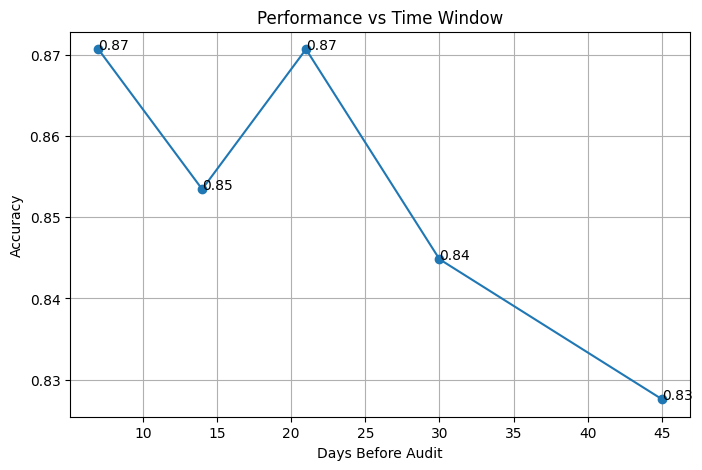

In [14]:
plt.figure(figsize=(8,5))

plt.plot(df_results['Days'], df_results['Accuracy'], marker='o')

for i, row in df_results.iterrows():
    plt.text(row['Days'], row['Accuracy'], f"{row['Accuracy']:.2f}")

plt.xlabel("Days Before Audit")
plt.ylabel("Accuracy")
plt.title("Performance vs Time Window")
plt.grid(True)

plt.show()